# STEP 1: Set Up the Environment

1. Open Jupyter Notebook (local) or Google Colab.

2. Create a new notebook named: performance_analysis.ipynb

3. Import the required modules:

In [1]:
import time
import multiprocessing
import cProfile

# STEP 2: Create a Sequential Program

## 1. Define a function that performs a compute-intensive task (e.g., summing squares of numbers).

In [4]:
def compute_sum(data):
  total = 0
  for x in data:
    total += x * x
  return total

## 2. Generate a large dataset:

In [5]:
data = list(range(1, 10_000_000))

## 3. Measure execution time of the sequential version:

In [6]:
start_time = time.time()
result = compute_sum(data)
end_time = time.time()
serial_time = end_time - start_time
print("Sequential Execution Time:", serial_time)

Sequential Execution Time: 0.6460306644439697


# STEP 3: Create a Parallel Version

## 1. Split the dataset into chunks:

In [9]:
def chunk_data(data, num_chunks):
  chunk_size = len(data) // num_chunks
  return [data[i*chunk_size:(i+1)*chunk_size] for i in range(num_chunks)]

  ## 2. Define a parallel computation using multiprocessing:

In [10]:
def parallel_compute(data):
  num_processes = multiprocessing.cpu_count()
  chunks = chunk_data(data, num_processes)
  with multiprocessing.Pool(processes=num_processes) as pool: results = pool.map(compute_sum, chunks)
  return sum(results)

## 3. Measure execution time of the parallel version:

In [11]:
start_time = time.time()
parallel_result = parallel_compute(data)
end_time = time.time()
parallel_time = end_time - start_time
print("Parallel Execution Time:", parallel_time)

Parallel Execution Time: 2.2597615718841553


# STEP 4: Calculate Speedup and Efficiency

## 1. Compute speedup:

In [13]:
speedup = serial_time / parallel_time
print("Speedup:", speedup)

Speedup: 0.2858844368723905


## 2. Compute efficiency:

In [14]:
num_processors = multiprocessing.cpu_count()
efficiency = speedup / num_processors
print("Efficiency:", efficiency)

Efficiency: 0.14294221843619526


## 3. Record results in a simple table:

  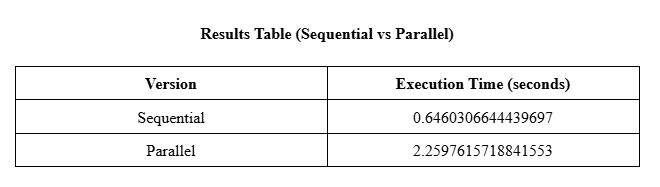

# STEP 5: Profile the Program (Identify Bottlenecks)

## 1. Profile the sequential version:

In [15]:
cProfile.run("compute_sum(data)")

         274 function calls (270 primitive calls) in 0.677 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.520    0.520    0.520    0.520 660579217.py:1(compute_sum)
        2    0.000    0.000    0.000    0.000 <frozen abc>:121(__subclasscheck__)
        3    0.000    0.000    0.000    0.000 <frozen importlib._bootstrap>:1390(_handle_fromlist)
        1    0.145    0.145    0.666    0.666 <string>:1(<module>)
        1    0.000    0.000    0.000    0.000 asyncio.py:231(add_callback)
        3    0.000    0.000    0.000    0.000 attrsettr.py:43(__getattr__)
        3    0.000    0.000    0.000    0.000 attrsettr.py:66(_get_attr_opt)
        2    0.000    0.000    0.676    0.338 base_events.py:1922(_run_once)
        1    0.000    0.000    0.000    0.000 base_events.py:2017(get_debug)
        1    0.000    0.000    0.000    0.000 base_events.py:543(_check_closed)
        1    0.000    0.000    0.000    0.000 b

## 2. Observe:
*   Which functions take the most time
*   Where optimization might help

There are 3 functions that took the most time to execute:
1. compute sum: 0.520 seconds - This function consumes the majority of the runtime.
2. module execution: 0.145 seconds - Time spent executing the script/module wrapper.
3. socket.send: 0.010 seconds - Minor overhead related to notebook/Jupyter communication.

Combining the runtime of these functions, they total to 0.677 seconds where compute sum took the most time. All other functions take almost negligible time which took around ≈0.000–0.01 seconds.

To optimize, it is necessary to focus on compute sum function. Improving the algorithm inside compute_sum such as implementing vectorization, optimized loops, or parallel computation would yield the largest performance improvement. Optimizing other functions would have minimal impact because their execution times are extremely small.


## 3. Write down one performance bottleneck you observe.

The compute_sum function is the main bottleneck because it consumes most of the execution time (0.520 s out of 0.677 s), indicating that the majority of processing occurs inside this function. Optimizing this function would significantly improve overall program performance.

# STEP 6: Apply One Simple Optimization

Choose one of the following:

* Option A: Reduce Loop Overhead

  Replace manual loop with built-in function: def compute_sum_optimized(data): return sum(x*x for x in data)

* Option B: Reduce Data Size per Process

  Adjust chunk size to improve load balance.

In [29]:
#Chose Option A:
def compute_sum_optimized(data):
  return sum(x*x for x in data)

def parallel_compute_optimized(data):
  num_processes = multiprocessing.cpu_count()
  chunks = chunk_data(data, num_processes)
  with multiprocessing.Pool(processes=num_processes) as pool: results = pool.map(compute_sum_optimized, chunks)
  return sum(results)

# STEP 7: Re-Test Performance

Measure execution time again after optimization.

Compare:

Original sequential

Parallel

Optimized version

In [42]:
# Original sequential
start_time = time.time()
result = compute_sum(data)
end_time = time.time()
serial_time = end_time - start_time
print("Sequential Execution Time:", serial_time)

Sequential Execution Time: 0.6630411148071289


In [43]:
# Original Parallel
start_time = time.time()
parallel_result = parallel_compute(data)
end_time = time.time()
parallel_time = end_time - start_time
print("Parallel Execution Time:", parallel_time)

Parallel Execution Time: 1.9583871364593506


In [44]:
# Sequential Optimized version
start_time = time.time()
result = compute_sum_optimized(data)
end_time = time.time()
serial_time = end_time - start_time
print("Optimized Sequential Execution Time:", serial_time)

Optimized Sequential Execution Time: 0.7973752021789551


In [45]:
# Parallel Optimized version
start_time = time.time()
parallel_result = parallel_compute_optimized(data)
end_time = time.time()
parallel_time = end_time - start_time
print("Optimized Parallel Execution Time:", parallel_time)

Optimized Parallel Execution Time: 2.201761245727539
